# Task 3 - Forest Cover Type Classification

Predicting which of 7 types of forest cover grows on a patch of land from its elevation, slope, distances, soil type and other features.
Dataset: Covertype from the UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/31/covertype), loaded with scikit-learn's fetch_covtype.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Loading the data

In [2]:
from sklearn.datasets import fetch_covtype

data = fetch_covtype(as_frame=True)
df = data.frame
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


## 2. Understanding the data
No missing values and no duplicates. The classes are very unbalanced: Lodgepole Pine and Spruce/Fir make up about 85% of the data.

In [3]:
df.shape

(581012, 55)

In [4]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [5]:
df[["Elevation", "Slope", "Horizontal_Distance_To_Roadways", "Hillshade_Noon"]].describe()

,Elevation,Slope,Horizontal_Distance_To_Roadways,Hillshade_Noon
count,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,14.103704,2350.146611,223.318716
std,279.984734,7.488242,1559.254870,19.768697
min,1859.000000,0.000000,0.000000,0.000000
25%,2809.000000,9.000000,1106.000000,213.000000
50%,2996.000000,13.000000,1997.000000,226.000000
75%,3163.000000,18.000000,3328.000000,237.000000
max,3858.000000,66.000000,7117.000000,254.000000


In [6]:
df["Cover_Type"].value_counts().sort_index()

,count
Cover_Type,
1,211840
2,283301
3,35754
4,2747
5,9493
6,17367
7,20510


## 3. Categorical features
Wilderness area and soil type are already one-hot encoded. I checked that every row has exactly one of each, and made a single Wilderness column only for exploring the data.

In [7]:
wilderness_cols = [c for c in df.columns if c.startswith("Wilderness")]
soil_cols = [c for c in df.columns if c.startswith("Soil")]

print("Wilderness columns:", len(wilderness_cols))
print("Soil columns:", len(soil_cols))

print("Rows with exactly one wilderness area:", (df[wilderness_cols].sum(axis=1) == 1).all())
print("Rows with exactly one soil type:", (df[soil_cols].sum(axis=1) == 1).all())

Wilderness columns: 4
Soil columns: 40
Rows with exactly one wilderness area: True
Rows with exactly one soil type: True


In [8]:
df["Wilderness"] = df[wilderness_cols].values.argmax(axis=1) + 1
df["Wilderness"].value_counts().sort_index()

,count
Wilderness,
1,260796
2,29884
3,253364
4,36968


## 4. Visualisation

In [13]:
cover_names = {1: "Spruce/Fir", 2: "Lodgepole Pine", 3: "Ponderosa Pine",
               4: "Cottonwood/Willow", 5: "Aspen", 6: "Douglas-fir", 7: "Krummholz"}
df["Cover_Name"] = df["Cover_Type"].map(cover_names)

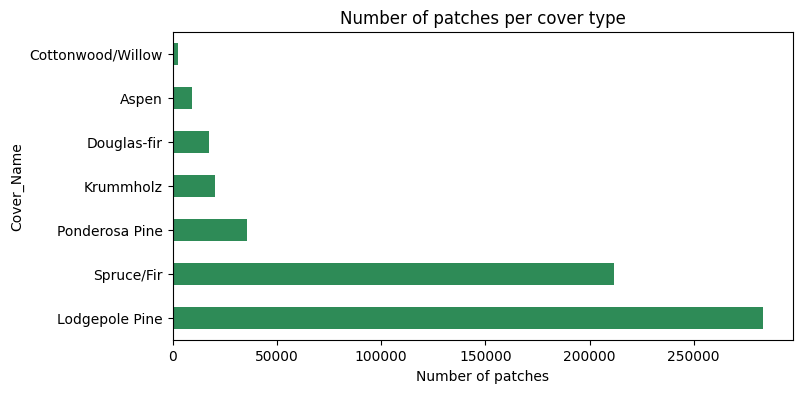

In [12]:
df["Cover_Name"].value_counts().plot(kind="barh", figsize=(8, 4), color="seagreen")
plt.title("Number of patches per cover type")
plt.xlabel("Number of patches")
plt.show()

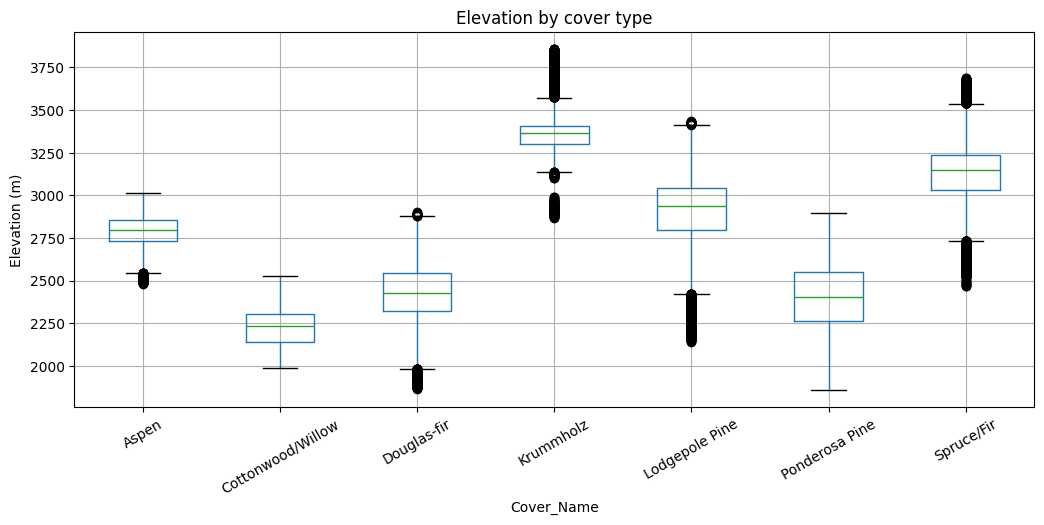

In [11]:
df.boxplot(column="Elevation", by="Cover_Name", figsize=(12, 5), rot=30)
plt.title("Elevation by cover type")
plt.suptitle("")
plt.ylabel("Elevation (m)")
plt.show()

## 5. Train/test split
80% training and 20% testing. I used stratify so both sets keep the same share of each tree type. Classes are changed from 1-7 to 0-6 because XGBoost needs them to start at 0.

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Cover_Type", "Cover_Name", "Wilderness"])
y = df["Cover_Type"] - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Features:", X.shape[1])
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Features: 54
Training rows: 464809
Test rows: 116203


## 6. Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

start = time.time()

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

print(f"Training took {time.time() - start:.0f} seconds")

rf_pred = rf.predict(X_test)
print(f"Random Forest accuracy: {accuracy_score(y_test, rf_pred):.4f}")

Training took 169 seconds
Random Forest accuracy: 0.9533


## 7. Evaluation

In [16]:
from sklearn.metrics import classification_report

class_labels = ["Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine", "Cottonwood/Willow",
                "Aspen", "Douglas-fir", "Krummholz"]

print(classification_report(y_test, rf_pred, target_names=class_labels, digits=3))

                   precision    recall  f1-score   support

       Spruce/Fir      0.963     0.941     0.952     42368
   Lodgepole Pine      0.948     0.973     0.960     56661
   Ponderosa Pine      0.939     0.960     0.950      7151
Cottonwood/Willow      0.916     0.856     0.885       549
            Aspen      0.954     0.770     0.852      1899
      Douglas-fir      0.930     0.890     0.910      3473
        Krummholz      0.973     0.946     0.959      4102

         accuracy                          0.953    116203
        macro avg      0.946     0.905     0.924    116203
     weighted avg      0.953     0.953     0.953    116203



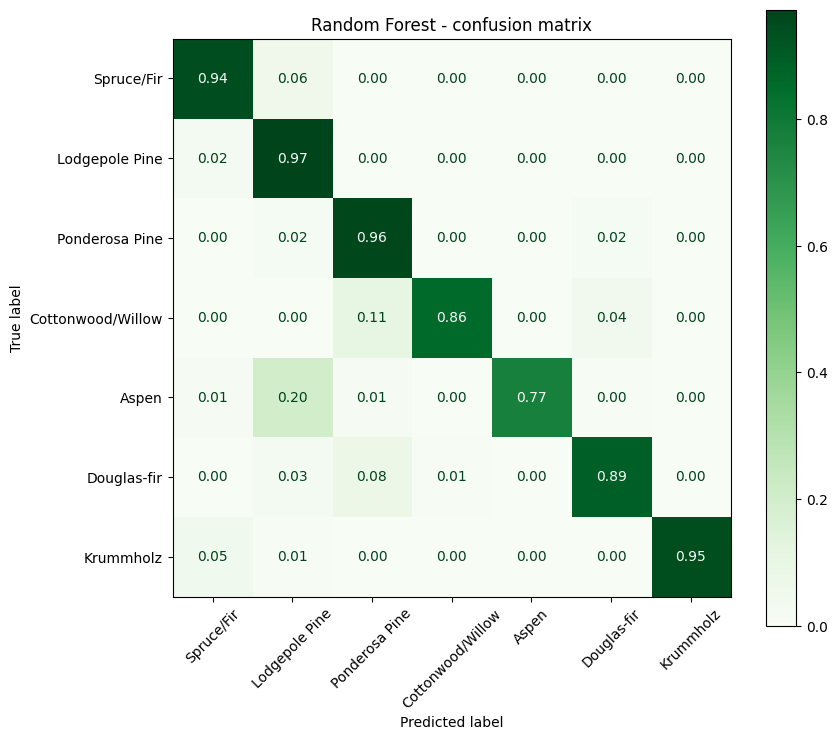

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=class_labels,
    normalize="true", values_format=".2f", cmap="Greens", ax=ax, xticks_rotation=45
)
plt.title("Random Forest - confusion matrix")
plt.show()

## 8. Feature importance

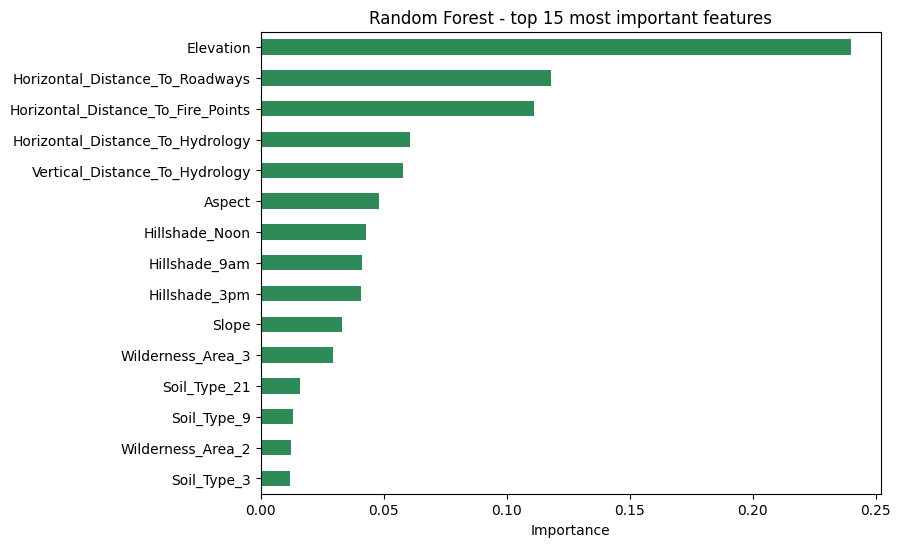

In [18]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

top15.sort_values().plot(kind="barh", figsize=(8, 6), color="seagreen")
plt.title("Random Forest - top 15 most important features")
plt.xlabel("Importance")
plt.show()

## 9. Bonus - XGBoost

In [20]:
from xgboost import XGBClassifier

start = time.time()

xgb = XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.2,
                    tree_method="hist", n_jobs=-1, random_state=42)
xgb.fit(X_train, y_train)

print(f"Training took {time.time() - start:.0f} seconds")

xgb_pred = xgb.predict(X_test)
print(f"XGBoost accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(classification_report(y_test, xgb_pred, target_names=class_labels, digits=3))

Training took 278 seconds
XGBoost accuracy: 0.9655
                   precision    recall  f1-score   support

       Spruce/Fir      0.970     0.959     0.964     42368
   Lodgepole Pine      0.966     0.976     0.971     56661
   Ponderosa Pine      0.960     0.966     0.963      7151
Cottonwood/Willow      0.902     0.856     0.879       549
            Aspen      0.939     0.878     0.908      1899
      Douglas-fir      0.941     0.930     0.936      3473
        Krummholz      0.971     0.969     0.970      4102

         accuracy                          0.966    116203
        macro avg      0.950     0.933     0.941    116203
     weighted avg      0.966     0.966     0.965    116203



## Conclusion

The dataset has 581,012 patches of land and 54 features, with no missing values or duplicates.
The wilderness area and soil type columns were already one-hot encoded, so I only checked that
they were correct. The classes are very unbalanced, so I also looked at macro F1 and the
results for each tree type, not only accuracy.

Random Forest got 95.3% accuracy and a macro F1 of 0.924.
XGBoost did better with 96.6% accuracy and a macro F1 of 0.941.

The rare tree types were the hardest to predict. Random Forest found only 77% of the Aspen
patches, and XGBoost improved this to 88%. Cottonwood/Willow stayed at about 86% for both models.

The confusion matrix shows that the model mostly mixes up trees that grow in similar places:
- 20% of Aspen was predicted as Lodgepole Pine
- 11% of Cottonwood/Willow and 8% of Douglas-fir were predicted as Ponderosa Pine
- some Krummholz was predicted as Spruce/Fir

Elevation was by far the most important feature, followed by the distances to roads,
fire points and water. This matches the box plot, where each tree type grows at a
different height.

Overall XGBoost is the better model for this task, especially for the rare tree types,
but it took longer to train.